In [1]:
import matplotlib.pyplot as plt
import pickle
import seaborn as sns
import pandas as pd
import numpy as np
import scipy
import json

In [2]:
df = pd.read_csv("../data/processed_dataset_wo_metals_w_even_more_qm2.csv")

In [3]:
y = df["solubility"]
X = df.drop(["solubility", "smiles", "canon_smiles", "id"], axis=1)

In [4]:
def get_coef(estimator) -> np.ndarray:
    return estimator.named_steps['predict'].coef_

In [5]:
import pickle

with open("HuberReg_RFE_combo_filtered.pkl", "rb") as f:
    filtered_data = pickle.load(f)

with open("HuberReg_RFE_combo.pkl", "rb") as f:
    data = pickle.load(f)

In [6]:
filtered_data

{'estimator': array([RFECV(cv=KFold(n_splits=5, random_state=40, shuffle=True),
              estimator=Pipeline(steps=[('variance', VarianceThreshold()),
                                        ('remove_corr',
                                         CorrelationFilter(threshold=0.95)),
                                        ('transform',
                                         PowerTransformer(standardize=False)),
                                        ('scale', StandardScaler()),
                                        ('predict',
                                         HuberRegressor(alpha=0.01, epsilon=2.0,
                                                        max_iter=1000))]),
              importance_getter=<function get_coef at 0x000001B80CD43CE0>, n_jobs=5,
              scoring='r2', verbose=12)                                             ,
        RFECV(cv=KFold(n_splits=5, random_state=40, shuffle=True),
              estimator=Pipeline(steps=[('variance', VarianceThr

In [13]:
filtered_data["test_r2"].mean(), data["test_r2"].mean() 

(np.float64(0.8215241585235021), np.float64(0.8165152090261439))

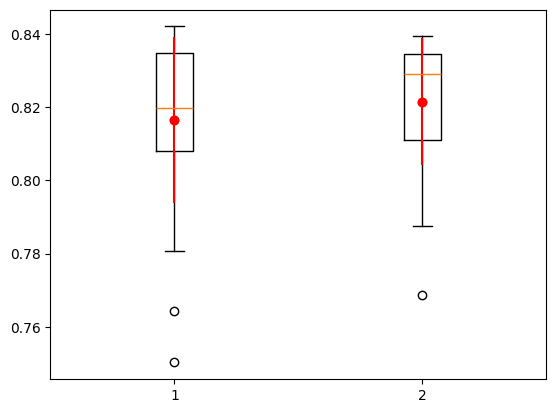

In [14]:
combo_r2s = data["test_r2"]
combo_filtered_r2s = filtered_data["test_r2"]
plt.boxplot([combo_r2s, combo_filtered_r2s])

means = [combo_r2s.mean(), combo_filtered_r2s.mean()]
stds = [combo_r2s.std(), combo_filtered_r2s.std()]

for i in range(len(means)):
   plt.plot(i + 1, means[i], 'ro')

for i in range(len(stds)):
   plt.errorbar(i + 1, means[i], yerr=stds[i], fmt='o', color='red')


plt.show()

In [33]:
def get_FI(estimator, how_many=20):
    FI = dict(zip(estimator.get_feature_names_out(), estimator.estimator_.named_steps["predict"].coef_))
    sorted_FI = dict(sorted(FI.items(), key=lambda item: abs(item[1]), reverse=True))
    keys = np.array(list(sorted_FI.keys())[:how_many])
    values = np.array(list(sorted_FI.values())[:how_many])
    return keys, values

In [34]:
best_combo_idx = data["test_r2"].argmax()
best_combo = data["estimator"][best_combo_idx]
keys_combo, values_combo = get_FI(best_combo)


# best_topo_idx = scores_topo_pure["test_r2"].argmax()
# best_topo = scores_topo_pure["estimator"][best_topo_idx]
# keys_topo, values_topo = get_FI(best_topo)

# best_qm_idx = scores_qm_pure2["test_r2"].argmax()
# best_qm = scores_qm_pure2["estimator"][best_qm_idx]
# keys_qm, values_qm = get_FI(best_qm)

In [76]:
X.filter(regex="coordination").columns

Index(['avg_effective_coordination_number',
       'min_effective_coordination_number',
       'max_effective_coordination_number',
       'std_effective_coordination_number'],
      dtype='str')

In [48]:
len(X.columns)

350

In [40]:
len(best_combo.get_feature_names_out())

344

In [74]:
best_combo.support_

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True, False, False,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

In [68]:
best_combo.ranking_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

Text(0.5, 1.0, 'Top 20 most important features')

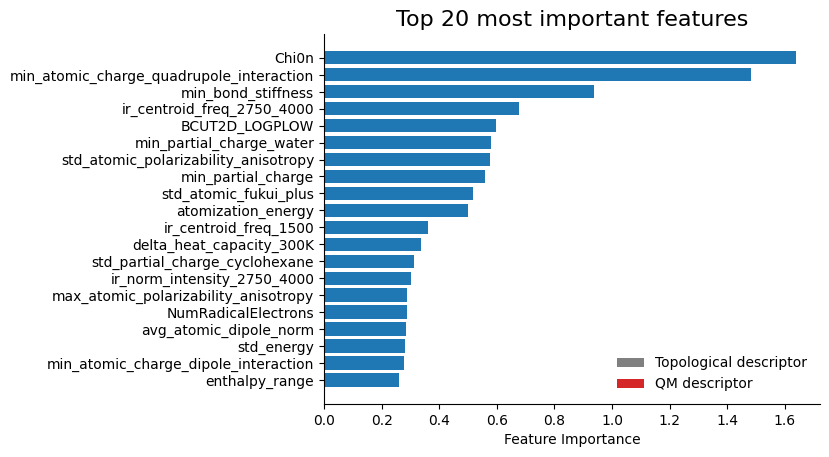

In [37]:
from matplotlib.patches import Patch

# colors = ["tab:red" if feature in X_qm_pure.columns else "grey" for feature in keys_combo]
# alphas = [1 if feature in X_qm_pure.columns else 0.6 for feature in keys_combo]

bars = plt.barh(keys_combo, abs(values_combo))

# for bar, alpha in zip(bars, alphas):
#     bar.set_alpha(alpha)

legend_elements = [
    Patch(facecolor="grey", label="Topological descriptor"),
    Patch(facecolor="tab:red", label="QM descriptor")
]

plt.legend(handles=legend_elements, frameon=False)

plt.gca().invert_yaxis()

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.xlabel("Feature Importance")
plt.title("Top 20 most important features", fontsize=16)

In [ ]:
# TO BE ADDED

In [ ]:
with open("../data/properties.json", "r") as f:
    data = json.load(f)

qm_feature_names = [feature["name_of_property"] for feature in data]

In [ ]:
scores_pre_rfe = cross_validate(pl_linear, X, y, cv=cv, scoring=scoring, n_jobs=4, return_estimator=True, return_train_score=True)

In [ ]:
scores_post_rfe = cross_validate(pl_linear, X_rfe, y, cv=cv, scoring=scoring, n_jobs=4, return_estimator=True, return_train_score=True)

In [ ]:
train_score_pre_rfe = scores_pre_rfe["train_r2"].mean()
test_score_pre_rfe = scores_pre_rfe["test_r2"].mean()
print(f"Pre-RFE:\nTrain score : {train_score_pre_rfe}\nTest score: {test_score_pre_rfe}\nDifference: {abs(test_score_pre_rfe - train_score_pre_rfe)}")

print("\n")

train_score_rfe = scores_post_rfe['train_r2'].mean()
test_score_rfe = scores_post_rfe['test_r2'].mean()
print(f"Post-RFE:\nTrain score : {train_score_rfe}\nTest score: {test_score_rfe}\nDifference: {abs(test_score_rfe - train_score_rfe)}")

Pre-RFE:
Train score : 0.8486718410870815
Test score: 0.8215690359567269
Difference: 0.027102805130354568


Post-RFE:
Train score : 0.848383203926588
Test score: 0.8229526949889514
Difference: 0.025430508937636542


The difference between the test and train score is for both situations small => no overfitting

In [ ]:
print(f"Pre-RFE R2 score: {scores_pre_rfe['test_r2'].mean()}\nPost-RFE R2 score: {scores_post_rfe['test_r2'].mean()}\nMean improvement: {(scores_post_rfe['test_r2'] - scores_pre_rfe['test_r2']).mean()}")
p_value = ttest_rel(scores_pre_rfe['test_r2'], scores_post_rfe['test_r2'])[1]
print(f"p-value: {p_value}")

Pre-RFE R2 score: 0.8215690359567269
Post-RFE R2 score: 0.8229526949889514
Mean improvement: 0.0013836590322244603
p-value: 0.12216066972413299


Despite the fact that the mean improvement of $R^2$ is so small, the increase is statistically significant. By reducing the amount of features with the RFE, we got an increase in performance.

In [ ]:
def get_best_pl(fit):
    return fit["estimator"][fit["test_r2"].argmax()]    

In [ ]:
best_post_rfe_pl = get_best_pl(scores_post_rfe)
best_pre_rfe_pl = get_best_pl(scores_pre_rfe)

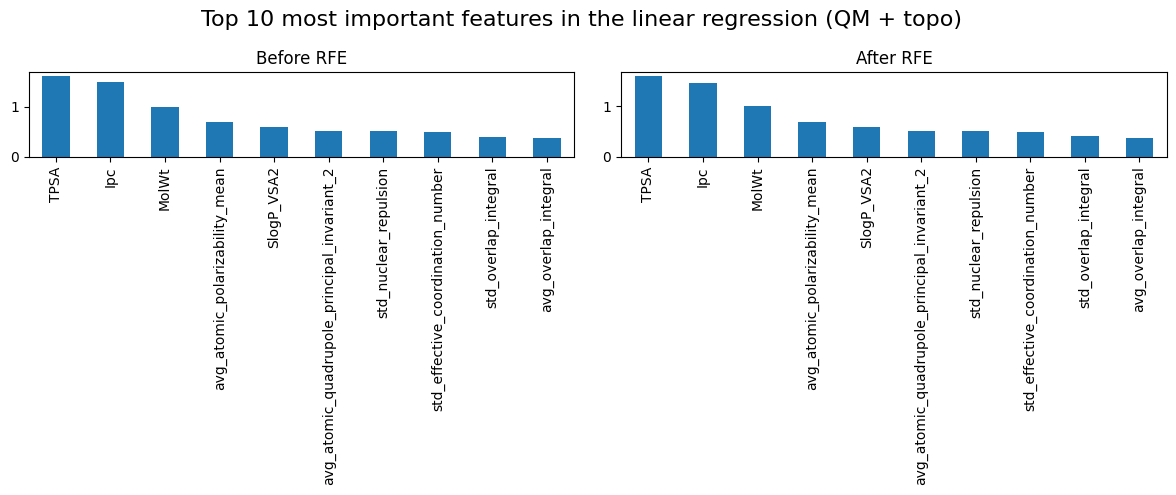

In [ ]:
pre_rfe_importance = pd.Series(
    best_pre_rfe_pl.named_steps["predict"].coef_,
    index=best_pre_rfe_pl[:-1].get_feature_names_out()
    )

post_rfe_importance = pd.Series(
    best_post_rfe_pl.named_steps["predict"].coef_,
    index=best_post_rfe_pl[:-1].get_feature_names_out()
    )

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

pre_rfe_importance.abs().sort_values(ascending=False)[:10].plot.bar(ax=ax[0])
ax[0].set_title("Before RFE")

post_rfe_importance.abs().sort_values(ascending=False)[:10].plot.bar(ax=ax[1])
ax[1].set_title("After RFE")

plt.suptitle("Top 10 most important features in the linear regression (QM + topo)", fontsize=16)
plt.tight_layout()
plt.show()